## Import package

In [1]:
import numpy as np
import pandas as pd

## Assigning new columns in method chains

Inspired by <u>dplyr's</u> `mutate` verb, DataFrame has <u>`assign`</u> method that allows you to easily create new columns that are potentially derived from existing columns.

In [2]:
warna = pd.read_csv("D:\\Dataset\\color_result.csv", sep=',', encoding='UTF-8')

In [3]:
warna.head()

,Red,Green,Blue
0,125,141,137
1,121,138,134
2,125,138,135
3,123,133,130
4,114,131,127


In [4]:
warna.assign(rata_rata = warna["Blue"] + warna["Green"] + warna ["Red"] / 3).head()

,Red,Green,Blue,rata_rata
0,125,141,137,319.666667
1,121,138,134,312.333333
2,125,138,135,314.666667
3,123,133,130,304.000000
4,114,131,127,296.000000


In the example above, we inserted a precomputed value. We can also pass in a function of one argument to be evaluated on the DataFrame being assingned to.

In [5]:
warna.assign(rata_rata_2 = lambda x: (x["Red"] + x["Green"] + x["Blue"] / 3)).head()

,Red,Green,Blue,rata_rata_2
0,125,141,137,311.666667
1,121,138,134,303.666667
2,125,138,135,308.000000
3,123,133,130,299.333333
4,114,131,127,287.333333


<u>`assign`</u> **always** returns a copy of the data, leaving the original DataFrame untouched.

Passing a callable, as opposed to an actual value to be inserted, is useful when you don't have a reference to the DataFrame at hand. This is common when using <u>`assign()`</u> in a chain of operations. For Examplem we can limit the DataFrame to just those observations with a rata_rata greater than 300, calculate the ratio, and plot:

<Axes: xlabel='avg_RG', ylabel='avg_GB'>

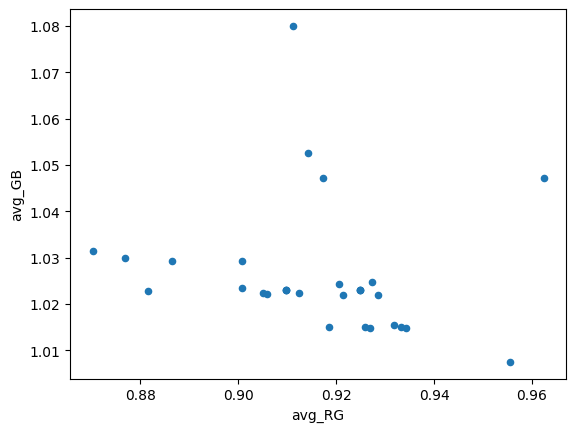

In [6]:
warna_with_rata = warna.assign(
    rata_rata_2 = lambda x: (x["Red"] + x["Green"] + x["Blue"] / 3)
)

(
    warna_with_rata.query("rata_rata_2 > 100")
    .assign(
        avg_RG = lambda x: x.Red / x.Green,
        avg_GB = lambda x: x.Green / x.Blue,
    )
    .plot(kind="scatter", x="avg_RG", y="avg_GB")
)

Since a function is passed in, the function is computed on the DataFrame being assigned to. Importantly, this is the DataFrame that’s been filtered to those rows with sepal length greater than 5. The filtering happens first, and then the ratio calculations. This is an example where we didn’t have a reference to the _filtered_ DataFrame available.

The function signature for <u>`assign()`</u> is simply <u>`**kwargs`</u>. The keys are the column names for the new fields, and the values are either a value to be inserted (for example, a <u>`Series`</u> or NumPy array), or a function of one argument to be called on the <u>`DataFrame`</u>. A copy of the original <u>`DataFrame`</u> is returned, with the new values inserted.

The order of <u>`**kwargs`</u> is preserved. This allows for _dependent_ assignment, where an expression later in <u>`**kwargs`</u> can refer to a column created earlier in the same <u>`assign()`</u>.

In [7]:
dfa = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})
dfa

,A,B
0,1,4
1,2,5
2,3,6


In [8]:
dfa.assign(C=lambda x: x["A"] + x["B"], d=lambda x: x["A"] + x["C"])

,A,B,C,d
0,1,4,5,6
1,2,5,7,9
2,3,6,9,12


In the second expression, `x['C']` will refer to the newly created column, that's equal to `dfa['A'] + dfa['B']`